<a href="https://colab.research.google.com/github/ai7dnn/2026-1-BDA/blob/main/code/11w1_ch06_dataframe_group_merge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **빅데이터분석프로그래밍**

# 파이썬 설치 확인

In [1]:
import site
site.getsitepackages()

['/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/lib/python3.12/dist-packages']

In [2]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns

print(sys.version)
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.2.2
2.0.2
0.13.2


# 코랩에서 한글 처리

In [11]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
# 그림 선명하게
%config InlineBackend.figure_format = 'retina'

In [12]:
# 데이터프레임의 소수점 이하 n(2)자리 출력 설정
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)  # 전역 적용

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]

In [21]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [20]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

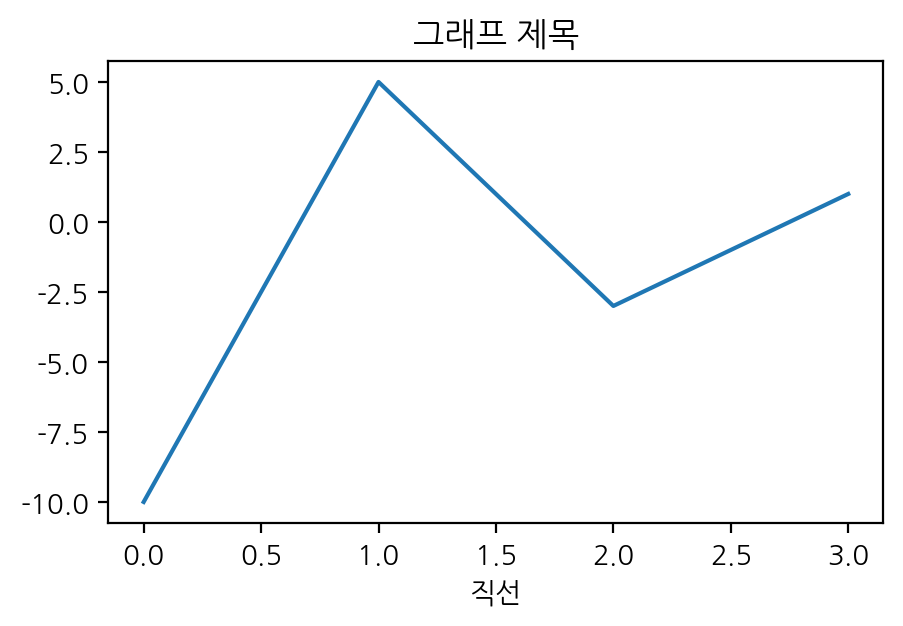

In [22]:
import matplotlib.pyplot as plt

plt.plot([-10, 5, -3, 1])
plt.title('그래프 제목')
plt.xlabel('직선')
plt.show()

## 수업에서 사용할 데이터를 다음 깃에서 복사
- https://github.com/ai7dnn/data.git

> #### 수업에서 파일 사용 시
> - 현재 하부 폴더: data
> - 파일: data/파일이름

In [14]:
!git clone https://github.com/ai7dnn/data.git

Cloning into 'data'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 50 (delta 12), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 5.71 MiB | 5.58 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [15]:
import pandas as pd

exam = pd.read_csv('data/exam.csv')
exam.head()

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65


In [17]:
exam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       20 non-null     int64
 1   nclass   20 non-null     int64
 2   math     20 non-null     int64
 3   english  20 non-null     int64
 4   science  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


In [18]:
exam.describe()

,id,nclass,math,english,science
count,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45
std,5.92,1.45,20.30,12.88,25.29
min,1.00,1.00,20.00,56.00,12.00
25%,5.75,2.00,45.75,78.00,45.00
50%,10.50,3.00,54.00,86.50,62.50
75%,15.25,4.00,75.75,98.00,78.00
max,20.00,5.00,90.00,98.00,98.00


In [23]:
display_side_by_side(exam.head(), exam.tail())

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
,id,nclass,math,english,science
15,16,4,58,98,65
16,17,5,65,68,98
17,18,5,80,78,90
18,19,5,89,68,87


## DataFrame.agg('sum') / Series.agg('sum')
- agg(aggregate)는 하나 이상의 집계 함수를 축(axis)을 따라 적용하는 메서드
- groupby, resample 이후 체이닝하거나 단독으로 사용
- 내장 집계 함수명
    - 'sum', 'mean', 'std', 'min', 'max', 'median', 'first', 'last', 'nunique' 등

In [24]:
exam.agg("mean")

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45


In [ ]:
exam.agg(["mean", "max", "min", "median"])

,id,nclass,math,english,science
mean,10.5,3.0,57.45,84.9,59.45
max,20.0,5.0,90.00,98.0,98.00
min,1.0,1.0,20.00,56.0,12.00
median,10.5,3.0,54.00,86.5,62.50


In [26]:
display_side_by_side(exam.agg(["mean", "max", "min", "median", "count"]), exam.describe())

,id,nclass,math,english,science
mean,10.50,3.00,57.45,84.90,59.45
max,20.00,5.00,90.00,98.00,98.00
min,1.00,1.00,20.00,56.00,12.00
median,10.50,3.00,54.00,86.50,62.50
count,20.00,20.00,20.00,20.00,20.00
,id,nclass,math,english,science
count,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45
std,5.92,1.45,20.30,12.88,25.29
min,1.00,1.00,20.00,56.00,12.00


In [27]:
exam.mean()

,0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45


In [29]:
display_series_side_by_side(exam.mean(), exam.agg("mean"))

,Series 0
id,10.50
nclass,3.00
math,57.45
english,84.90
science,59.45
,Series 1
id,10.50
nclass,3.00
math,57.45
english,84.90


In [30]:
exam.agg(mean_math = ('math', 'mean'))

,math
mean_math,57.45


In [31]:
import numpy as np
df = pd.DataFrame([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9],
                   [np.nan, np.nan, 10]],
                   columns=['A', 'B', 'C'])
df

,A,B,C
0,1.00,2.00,3
1,4.00,5.00,6
2,7.00,8.00,9
3,NaN,NaN,10


In [32]:
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'])

,A,B,C
sum,12.00,15.00,28.00
mean,4.00,5.00,7.00
median,4.00,5.00,7.50
min,1.00,2.00,3.00
max,7.00,8.00,10.00
count,3.00,3.00,4.00


In [34]:
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'], axis=0)

,A,B,C
sum,12.00,15.00,28.00
mean,4.00,5.00,7.00
median,4.00,5.00,7.50
min,1.00,2.00,3.00
max,7.00,8.00,10.00
count,3.00,3.00,4.00


In [ ]:
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'], axis='index')

,A,B,C
sum,12.0,15.0,28.0
mean,4.0,5.0,7.0
median,4.0,5.0,7.5
min,1.0,2.0,3.0
max,7.0,8.0,10.0
count,3.0,3.0,4.0


In [36]:
df

,A,B,C
0,1.00,2.00,3
1,4.00,5.00,6
2,7.00,8.00,9
3,NaN,NaN,10


In [35]:
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'], axis=1)

,sum,mean,median,min,max,count
0,6.00,2.00,2.00,1.00,3.00,3.00
1,15.00,5.00,5.00,4.00,6.00,3.00
2,24.00,8.00,8.00,7.00,9.00,3.00
3,10.00,10.00,10.00,10.00,10.00,1.00


In [37]:
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'], axis='columns')

,sum,mean,median,min,max,count
0,6.00,2.00,2.00,1.00,3.00,3.00
1,15.00,5.00,5.00,4.00,6.00,3.00
2,24.00,8.00,8.00,7.00,9.00,3.00
3,10.00,10.00,10.00,10.00,10.00,1.00


#### 집단별 요약 통계량 구하기

In [38]:
exam

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
5,6,2,50,89,98
6,7,2,80,90,45
7,8,2,90,78,25
8,9,3,20,98,15
9,10,3,50,98,45


### groupby('category').agg() — 카테고리 별로 집계함수 사용 패턴

```Python
df.groupby('category').agg(
    total_sales  = ('sales',  'sum'),
    avg_price    = ('price',  'mean'),
    n_items      = ('item_id', 'count'),
    price_range  = ('price',  lambda x: x.max() - x.min())
)
```
> Named aggregation 문법(컬럼명=(원본컬럼, 함수))
> - pandas 0.25+에서 지원하며 결과 컬럼명을 직접 지정할 수 있어 가독성이 높습니다.

In [39]:
exam.groupby('nclass').agg(mean_math = ('math', 'mean'))

,mean_math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [40]:
exam.groupby('nclass').agg(max_math = ('math', 'max'))

,max_math
nclass,
1,60
2,90
3,65
4,75
5,89


In [41]:
exam.groupby('nclass').mean()

,id,math,english,science
nclass,,,,
1,2.50,46.25,94.75,61.50
2,6.50,61.25,84.25,58.25
3,10.50,45.00,86.50,39.25
4,14.50,56.75,84.75,55.00
5,18.50,78.00,74.25,83.25


In [42]:
exam.groupby('nclass').mean()[["math"]]

,math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [43]:
exam.groupby('nclass').mean()[["math", "english", "science"]]

,math,english,science
nclass,,,
1,46.25,94.75,61.50
2,61.25,84.25,58.25
3,45.00,86.50,39.25
4,56.75,84.75,55.00
5,78.00,74.25,83.25


In [44]:
exam.groupby('nclass').min()

,id,math,english,science
nclass,,,,
1,1,30,86,50
2,5,25,78,25
3,9,20,65,15
4,13,46,56,12
5,17,65,68,58


In [45]:
exam.groupby('nclass').agg("mean")

,id,math,english,science
nclass,,,,
1,2.50,46.25,94.75,61.50
2,6.50,61.25,84.25,58.25
3,10.50,45.00,86.50,39.25
4,14.50,56.75,84.75,55.00
5,18.50,78.00,74.25,83.25


In [ ]:
exam.groupby('nclass').agg(["mean", "median"])

id          math        english        science       
        mean median   mean median    mean median    mean median
nclass                                                         
1        2.5    2.5  46.25   47.5   94.75   97.5   61.50   59.0
2        6.5    6.5  61.25   65.0   84.25   84.5   58.25   55.0
3       10.5   10.5  45.00   47.5   86.50   91.5   39.25   38.5
4       14.5   14.5  56.75   53.0   84.75   92.5   55.00   65.0
5       18.5   18.5  78.00   79.0   74.25   73.0   83.25   88.5

### 인자 사용 방법
- 열 이름은 키워드인 반면, 값 ('열명', '함수명')은 열에서 값을 계산하는 데 사용되는 함수 이름
- 새_열이름 = ('열명', '함수명')


In [46]:
exam.groupby('nclass').agg(meanMath = ('math', 'mean'))

,meanMath
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [47]:
exam.groupby('nclass').agg(meanMath = ('math', 'mean'), meanEng = ('english', 'mean'))

,meanMath,meanEng
nclass,,
1,46.25,94.75
2,61.25,84.25
3,45.00,86.50
4,56.75,84.75
5,78.00,74.25


### 인자 사용 방법: 사전 형식
- {'열명': '함수명'}

In [48]:
exam.groupby('nclass').agg({'math': 'mean'})

,math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


### dict of axis labels -> functions, function names or list of such.
- {'열명': ['함수명1', '함수명2', ...]}

In [ ]:
exam.groupby('nclass').agg({'math': ['mean', 'min', 'max']})

math        
         mean min max
nclass               
1       46.25  30  60
2       61.25  25  90
3       45.00  20  65
4       56.75  46  75
5       78.00  65  89

In [49]:
edf = exam.groupby('nclass').agg({'math': ['mean', 'min', 'max']})
edf.columns

MultiIndex([('math', 'mean'),
            ('math',  'min'),
            ('math',  'max')],
           )

### (알아 두면 좋아요) 변수를 인덱스로 바꾸지 않기

In [50]:
# nclass가 index가 됨
exam.groupby('nclass').agg(mean_math = ('math', 'mean'))

,mean_math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


In [52]:
# 인자 as_index=False: nclass가 index가 안됨
exam.groupby('nclass', as_index=False).agg(mean_math = ('math', 'mean'))

,nclass,mean_math
0,1,46.25
1,2,61.25
2,3,45.00
3,4,56.75
4,5,78.00


위까지 1교시

### groupby()
- 특정 기준으로 데이터를 묶은 뒤, 묶인 그룹마다 통계나 변환을 수행하는 기능

### DataFrameGroupBy 객체

In [53]:
exam.groupby('nclass')

In [54]:
type(exam.groupby('nclass'))

pandas.core.groupby.generic.DataFrameGroupBy

In [55]:
range(10)

range(0, 10)

In [56]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [57]:
exam_gb = exam.groupby('nclass')
exam_gb

In [58]:
list(exam_gb)

[(1,
     id  nclass  math  english  science
  0   1       1    50       98       50
  1   2       1    60       97       60
  2   3       1    45       86       78
  3   4       1    30       98       58),
 (2,
     id  nclass  math  english  science
  4   5       2    25       80       65
  5   6       2    50       89       98
  6   7       2    80       90       45
  7   8       2    90       78       25),
 (3,
      id  nclass  math  english  science
  8    9       3    20       98       15
  9   10       3    50       98       45
  10  11       3    65       65       65
  11  12       3    45       85       32),
 (4,
      id  nclass  math  english  science
  12  13       4    46       98       65
  13  14       4    48       87       12
  14  15       4    75       56       78
  15  16       4    58       98       65),
 (5,
      id  nclass  math  english  science
  16  17       5    65       68       98
  17  18       5    80       78       90
  18  19       5    89       68   

In [59]:
exam_gb.groups

{1: [0, 1, 2, 3], 2: [4, 5, 6, 7], 3: [8, 9, 10, 11], 4: [12, 13, 14, 15], 5: [16, 17, 18, 19]}

In [64]:
for key, value in exam_gb:
    print(key)
    print(type(value))
    print(value)
    print('='*40, '\n')

1
<class 'pandas.core.frame.DataFrame'>
   id  nclass  math  english  science
0   1       1    50       98       50
1   2       1    60       97       60
2   3       1    45       86       78
3   4       1    30       98       58

2
<class 'pandas.core.frame.DataFrame'>
   id  nclass  math  english  science
4   5       2    25       80       65
5   6       2    50       89       98
6   7       2    80       90       45
7   8       2    90       78       25

3
<class 'pandas.core.frame.DataFrame'>
    id  nclass  math  english  science
8    9       3    20       98       15
9   10       3    50       98       45
10  11       3    65       65       65
11  12       3    45       85       32

4
<class 'pandas.core.frame.DataFrame'>
    id  nclass  math  english  science
12  13       4    46       98       65
13  14       4    48       87       12
14  15       4    75       56       78
15  16       4    58       98       65

5
<class 'pandas.core.frame.DataFrame'>
    id  nclass  math  engl

#### 여러 요약 통계량 한 번에 구하기

### nclass별로 분리
- 수학 점수 평균
- 수학 점수 합계
- 수학 점수 중앙값
- 빈도(학생 수)

In [ ]:
exam.groupby('nclass').agg(mean_math   = ('math', 'mean'),
                           sum_math    = ('math', 'sum'),
                           median_math = ('math', 'median'),
                           count       = ('nclass', 'count'))

,mean_math,sum_math,median_math,count
nclass,,,,
1,46.25,185,47.5,4
2,61.25,245,65.0,4
3,45.00,180,47.5,4
4,56.75,227,53.0,4
5,78.00,312,79.0,4


### (알아 두면 좋아요) 모든 변수의 요약 통계량 한 번에 구하기

In [65]:
exam.groupby('nclass').mean()

,id,math,english,science
nclass,,,,
1,2.50,46.25,94.75,61.50
2,6.50,61.25,84.25,58.25
3,10.50,45.00,86.50,39.25
4,14.50,56.75,84.75,55.00
5,18.50,78.00,74.25,83.25


In [66]:
exam.groupby('nclass').agg(['mean', 'median'])

id         math        english        science       
        mean median  mean median    mean median    mean median
nclass                                                        
1       2.50   2.50 46.25  47.50   94.75  97.50   61.50  59.00
2       6.50   6.50 61.25  65.00   84.25  84.50   58.25  55.00
3      10.50  10.50 45.00  47.50   86.50  91.50   39.25  38.50
4      14.50  14.50 56.75  53.00   84.75  92.50   55.00  65.00
5      18.50  18.50 78.00  79.00   74.25  73.00   83.25  88.50

### 집단별로 다시 집단 나누기

### mpg 데이터
- 1999-2008년 234개 자동차 모델의 연비 및 스펙을 포함

| 열 이름         | 데이터 타입 | 설명                          |
| ------------ | ------ | --------------------------- |
| manufacturer | object | 자동차 제조사 이름                  |
| model        | object | 자동차 모델명                     |
| displ        | float  | 엔진 배기량 (litres)             |
| year         | int    | 생산 연도                       |
| cyl          | int    | 실린더 수                       |
| trans        | object | 변속기 타입 (auto/manual 등)      |
| drv          | object | 구동 방식 (f, r, 4)             |
| cty          | int    | 도시 도로 연비 (miles per gallon) |
| hwy          | int    | 고속도로 연비 (miles per gallon)  |
| fl           | object | 연료 타입 (regular, premium 등)  |
| category        | object | 차종 클래스 (suv, compact 등)     |


In [68]:
import pandas as pd

mpg = pd.read_csv('data/mpg.csv')
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  category      234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 20.2+ KB


In [69]:
mpg.columns

Index(['manufacturer', 'model', 'displ', 'year', 'cyl', 'trans', 'drv', 'cty',
       'hwy', 'fl', 'category'],
      dtype='object')

In [70]:
mpg.sample(frac=.02)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
185,toyota,camry,3.50,2008,6,auto(s6),f,19,28,r,midsize
45,dodge,caravan 2wd,3.80,1999,6,auto(l4),f,15,21,r,minivan
54,dodge,dakota pickup 4wd,4.70,2008,8,auto(l5),4,9,12,e,pickup
13,audi,a4 quattro,3.10,2008,6,auto(s6),4,17,25,p,compact
57,dodge,durango 4wd,3.90,1999,6,auto(l4),4,13,17,r,suv


In [71]:
# 제조 회사 및 구동 방식별 분리
# cty 평균 구하기
mpg.groupby(['manufacturer', 'drv']).agg(mean_cty = ('cty', 'mean')) # 시험 예상

mean_cty
manufacturer drv          
audi         4       16.82
             f       18.86
chevrolet    4       12.50
             f       18.80
             r       14.10
dodge        4       12.00
             f       15.82
ford         4       13.31
             r       14.75
honda        f       24.44
hyundai      f       18.64
jeep         4       13.50
land rover   4       11.50
lincoln      r       11.33
mercury      4       13.25
nissan       4       13.75
             f       20.00
pontiac      f       17.00
subaru       4       19.29
toyota       4       14.93
             f       21.37
volkswagen   f       20.93

In [72]:
mpg.groupby(['drv', 'manufacturer']).agg(mean_cty = ('cty', 'mean')) # 시험 예상

mean_cty
drv manufacturer          
4   audi             16.82
    chevrolet        12.50
    dodge            12.00
    ford             13.31
    jeep             13.50
    land rover       11.50
    mercury          13.25
    nissan           13.75
    subaru           19.29
    toyota           14.93
f   audi             18.86
    chevrolet        18.80
    dodge            15.82
    honda            24.44
    hyundai          18.64
    nissan           20.00
    pontiac          17.00
    toyota           21.37
    volkswagen       20.93
r   chevrolet        14.10
    ford             14.75
    lincoln          11.33

In [73]:
mdf = mpg.groupby(['drv', 'manufacturer']).agg(mean_cty = ('cty', 'mean'))
mdf.sort_values('mean_cty', ascending = False)

mean_cty
drv manufacturer          
f   honda            24.44
    toyota           21.37
    volkswagen       20.93
    nissan           20.00
4   subaru           19.29
f   audi             18.86
    chevrolet        18.80
    hyundai          18.64
    pontiac          17.00
4   audi             16.82
f   dodge            15.82
4   toyota           14.93
r   ford             14.75
    chevrolet        14.10
4   nissan           13.75
    jeep             13.50
    ford             13.31
    mercury          13.25
    chevrolet        12.50
    dodge            12.00
    land rover       11.50
r   lincoln          11.33

In [77]:
# 4륜, 전륜(f), 후륜(r) 중에서 연비 순으로 정렬
mdf.sort_values(['drv', 'mean_cty'], ascending=[True, False])

mean_cty
drv manufacturer          
4   subaru           19.29
    audi             16.82
    toyota           14.93
    nissan           13.75
    jeep             13.50
    ford             13.31
    mercury          13.25
    chevrolet        12.50
    dodge            12.00
    land rover       11.50
f   honda            24.44
    toyota           21.37
    volkswagen       20.93
    nissan           20.00
    audi             18.86
    chevrolet        18.80
    hyundai          18.64
    pontiac          17.00
    dodge            15.82
r   ford             14.75
    chevrolet        14.10
    lincoln          11.33

In [76]:
mdf.index

MultiIndex([('4',       'audi'),
            ('4',  'chevrolet'),
            ('4',      'dodge'),
            ('4',       'ford'),
            ('4',       'jeep'),
            ('4', 'land rover'),
            ('4',    'mercury'),
            ('4',     'nissan'),
            ('4',     'subaru'),
            ('4',     'toyota'),
            ('f',       'audi'),
            ('f',  'chevrolet'),
            ('f',      'dodge'),
            ('f',      'honda'),
            ('f',    'hyundai'),
            ('f',     'nissan'),
            ('f',    'pontiac'),
            ('f',     'toyota'),
            ('f', 'volkswagen'),
            ('r',  'chevrolet'),
            ('r',       'ford'),
            ('r',    'lincoln')],
           names=['drv', 'manufacturer'])

In [78]:
# 제조 회사와 차종별 분리
# cty 평균 구하기
# hwy 평균 구하기
mpg.groupby(['manufacturer', 'category']).agg(mean_cty = ('cty', 'mean'), mean_hwy = ('hwy', 'mean'))

mean_cty  mean_hwy
manufacturer category                      
audi         compact        17.93     26.93
             midsize        16.00     24.00
chevrolet    2seater        15.40     24.80
             midsize        18.80     27.60
             suv            12.67     17.11
dodge        minivan        15.82     22.36
             pickup         12.05     16.11
             suv            11.86     16.00
ford         pickup         13.00     16.43
             subcompact     15.89     23.22
             suv            12.89     17.78
honda        subcompact     24.44     32.56
hyundai      midsize        19.00     27.71
             subcompact     18.29     26.00
jeep         suv            13.50     17.62
land rover   suv            11.50     16.50
lincoln      suv            11.33     17.00
mercury      suv            13.25     18.00
nissan       compact        20.00     28.00
             midsize        20.00     27.43
             suv            13.75     18.00
pontiac      midsize        17.00     26.40
subaru       compact        19.75     26.00
             subcompact     19.50     26.00
             suv            18.83     25.00
toyota       compact        22.25     30.58
             midsize        19.86     28.29
             pickup         15.57     19.43
             suv            14.38     18.25
volkswagen   compact        20.79     28.50
             midsize        18.57     27.57
             subcompact     24.00     32.83

In [79]:
## audi의 drv별 빈도

# audi 추출
# drv별 분리
# 빈도 구하기
mpg.query('manufacturer == "audi"').groupby(['drv']).agg(n = ('drv', 'count'))

,n
drv,
4,11
f,7


In [82]:
mpg[ (mpg.manufacturer == "audi") & (mpg.drv.isin(['4', 'r', 'f'])) ]

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.80,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.80,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.00,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.00,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.80,1999,6,auto(l5),f,16,26,p,compact
5,audi,a4,2.80,1999,6,manual(m5),f,18,26,p,compact
6,audi,a4,3.10,2008,6,auto(av),f,18,27,p,compact
7,audi,a4 quattro,1.80,1999,4,manual(m5),4,18,26,p,compact
8,audi,a4 quattro,1.80,1999,4,auto(l5),4,16,25,p,compact
9,audi,a4 quattro,2.00,2008,4,manual(m6),4,20,28,p,compact


In [83]:
mpg.query("manufacturer == 'audi' and drv in ['4', 'r', 'f']")

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.80,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.80,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.00,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.00,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.80,1999,6,auto(l5),f,16,26,p,compact
5,audi,a4,2.80,1999,6,manual(m5),f,18,26,p,compact
6,audi,a4,3.10,2008,6,auto(av),f,18,27,p,compact
7,audi,a4 quattro,1.80,1999,4,manual(m5),4,18,26,p,compact
8,audi,a4 quattro,1.80,1999,4,auto(l5),4,16,25,p,compact
9,audi,a4 quattro,2.00,2008,4,manual(m6),4,20,28,p,compact


In [86]:
## chevrolet의 drv별 빈도

# chevrolet 추출
# drv별 분리
# 빈도 구하기
mpg.query('manufacturer == "chevrolet"') \
   .groupby(['drv']).agg(n = ('drv', 'count'))

,n
drv,
4,4
f,5
r,10


In [85]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()

,manufacturer,model,displ,year,cyl,trans,cty,hwy,fl,category
drv,,,,,,,,,,
4,4,4,4,4,4,4,4,4,4,4
f,5,5,5,5,5,5,5,5,5,5
r,10,10,10,10,10,10,10,10,10,10


In [87]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()[['model']]

,model
drv,
4,4
f,5
r,10


In [88]:
mpg.query('manufacturer == "chevrolet"').groupby(['drv']).count()[['model']].rename(columns = {'model' : 'n'})

,n
drv,
4,4
f,5
r,10


#### (알아 두면 좋아요) `value_counts()`로 집단별 빈도 간단하게 구하기

In [89]:
mpg.groupby('drv').agg(n = ('drv', 'count'))

,n
drv,
4,103
f,106
r,25


In [91]:
mpg[['drv', 'cyl']].value_counts()

drv  cyl
f    4      58
4    8      48
f    6      43
4    6      32
     4      23
r    8      21
f    5       4
r    6       4
f    8       1
Name: count, dtype: int64

In [92]:
mpg[['drv', 'cyl']].value_counts().to_frame()

count
drv cyl       
f   4       58
4   8       48
f   6       43
4   6       32
    4       23
r   8       21
f   5        4
r   6        4
f   8        1

In [97]:
mpg['drv'].value_counts().query('count > 100') # 오류 발생

AttributeError: 'Series' object has no attribute 'query'

In [98]:
mpg['drv'].value_counts().to_frame().query('count > 100')

,count
drv,
f,106
4,103


2교시까지

In [105]:
mpg['drv'].value_counts() \
          .to_frame('n')

,n
drv,
f,106
4,103
r,25


In [104]:
# drv 빈도 구하기
# 데이터 프레임으로 바꾸기, 변수명 n으로 바꾸기
# axis 이름에 drv 지정
# n이 100을 초과한 경우 추출
mpg['drv'].value_counts() \
          .to_frame('n') \
          .query('n > 100')

,n
drv,
f,106
4,103


In [103]:
mpg['drv'].value_counts().to_frame('n') # 열 제목

,n
drv,
f,106
4,103
r,25


In [106]:
mpg.groupby('drv').agg(n = ('drv', 'count'))

,n
drv,
4,103
f,106
r,25


In [107]:
mpg.groupby('drv').agg(n = ('drv', 'count')).query('n > 100')

,n
drv,
4,103
f,106


### `pandas` 함수 조합하기

In [110]:
# suv 추출
# 합산 연비 변수 만들기
# 제조 회사별로 분리
# 합산 연비 평균 구하기
# 내림차순 정렬
# 1~5위까지 출력, 시험 예상
mpg.query('category == "suv"') \
   .assign(total = (mpg['hwy'] + mpg['cty']) / 2) \
   .groupby('manufacturer') \
   .agg(mean_tot = ('total', 'mean')) \
   .sort_values('mean_tot', ascending = False) \
   .head(5)

,mean_tot
manufacturer,
subaru,21.92
toyota,16.31
nissan,15.88
mercury,15.62
jeep,15.56


In [111]:
mpg.query('category == "suv"') \
   .assign(total = (mpg['hwy'] + mpg['cty']) / 2) \
   .groupby('manufacturer') \
   .agg(mean_tot = ('total', 'mean')) \
   .sort_values('mean_tot', ascending = False)

,mean_tot
manufacturer,
subaru,21.92
toyota,16.31
nissan,15.88
mercury,15.62
jeep,15.56
ford,15.33
chevrolet,14.89
lincoln,14.17
land rover,14.00


## 혼자서 해보기

## 06-7 데이터 합치기

In [112]:
# 중간고사 데이터 만들기
test1 = pd.DataFrame({'id'      : [1, 2, 3, 4, 5],
                      'midterm' : [60, 80, 70, 90, 85]})

# 기말고사 데이터 만들기
test2 = pd.DataFrame({'id'    : [1, 2, 3, 4, 5],
                      'final' : [70, 83, 65, 95, 80]})

In [113]:
display_side_by_side(test1, test2)

,id,midterm
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
,id,final
0,1,70
1,2,83
2,3,65
3,4,95


In [114]:
pd.merge(test1, test2)

,id,midterm,final
0,1,60,70
1,2,80,83
2,3,70,65
3,4,90,95
4,5,85,80


In [115]:
pd.merge(test1, test2, on = 'id')

,id,midterm,final
0,1,60,70
1,2,80,83
2,3,70,65
3,4,90,95
4,5,85,80


In [116]:
pd.merge(test1, test2, on = 'id', how = 'inner')

,id,midterm,final
0,1,60,70
1,2,80,83
2,3,70,65
3,4,90,95
4,5,85,80


In [117]:
test1.merge(test2, on = 'id', how = 'inner')

,id,midterm,final
0,1,60,70
1,2,80,83
2,3,70,65
3,4,90,95
4,5,85,80


In [118]:
display_side_by_side(test1, test2)

,id,midterm
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
,id,final
0,1,70
1,2,83
2,3,65
3,4,95


#### 다른 데이터를 활용해 변수 추가하기

In [119]:
name = pd.DataFrame({'nclass'  : [1, 2, 3, 4, 5],
                     'teacher' : ['kim', 'lee', 'park', 'choi', 'jung']})
name

,nclass,teacher
0,1,kim
1,2,lee
2,3,park
3,4,choi
4,5,jung


In [120]:
exam.sample(5)

,id,nclass,math,english,science
11,12,3,45,85,32
13,14,4,48,87,12
7,8,2,90,78,25
2,3,1,45,86,78
17,18,5,80,78,90


In [121]:
display_side_by_side(exam.sample(5), name)

id 
 nclass 
 math 
 english 
 science 
 
 
 
 
 9 
 10 
 3 
 50 
 98 
 45 
 
 
 6 
 7 
 2 
 80 
 90 
 45 
 
 
 0 
 1 
 1 
 50 
 98 
 50 
 
 
 17 
 18 
 5 
 80 
 78 
 90 
 
 
 15 
 16 
 4 
 58 
 98 
 65 
 
 
      
 
 
 
 nclass 
 teacher 
 
 
 
 
 0 
 1 
 kim 
 
 
 1 
 2 
 lee 
 
 
 2 
 3 
 park 
 
 
 3 
 4 
 choi 
 
 
 4 
 5 
 jung

In [122]:
pd.merge(exam, name, on ='nclass', how = 'inner')

,id,nclass,math,english,science,teacher
0,1,1,50,98,50,kim
1,2,1,60,97,60,kim
2,3,1,45,86,78,kim
3,4,1,30,98,58,kim
4,5,2,25,80,65,lee
5,6,2,50,89,98,lee
6,7,2,80,90,45,lee
7,8,2,90,78,25,lee
8,9,3,20,98,15,park
9,10,3,50,98,45,park


### 세로로 합치기: concat()

In [124]:
# 학생 1~5번 시험 데이터 만들기
group_a = pd.DataFrame({'id'   : [1, 2, 3, 4, 5],
                        'test' : [60, 80, 70, 90, 85]})

# 학생 6~10번 시험 데이터 만들기
group_b = pd.DataFrame({'id'   : [6, 7, 8, 9, 10],
                        'test' : [70, 83, 65, 95, 80]})

In [126]:
display_side_by_side(group_a, group_b)

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
,id,test
0,6,70
1,7,83
2,8,65
3,9,95


In [127]:
pd.concat([group_a, group_b])

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
0,6,70
1,7,83
2,8,65
3,9,95
4,10,80


In [128]:
pd.concat([group_a, group_b]).reset_index() # 원 index가 열로 이동, 새로운 시퀀스 지정

,index,id,test
0,0,1,60
1,1,2,80
2,2,3,70
3,3,4,90
4,4,5,85
5,0,6,70
6,1,7,83
7,2,8,65
8,3,9,95
9,4,10,80


In [129]:
pd.concat([group_a, group_b]).reset_index(drop = True) # 원 index 제거, 새로운 시퀀스 지정

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
5,6,70
6,7,83
7,8,65
8,9,95
9,10,80


# **merge() 시험 예상**

In [130]:
import pandas as pd

df1 = pd.DataFrame([[1, 'apple'], [2, 'banana']],
                  columns = ['id', 'fruits'])
df1

,id,fruits
0,1,apple
1,2,banana


In [132]:
df2 = pd.DataFrame([[1, 3000], [5, 500]],
                  columns = ['id', 'price'])
df2

,id,price
0,1,3000
1,5,500


In [134]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [135]:
pd.merge(df1, df2)

,id,fruits,price
0,1,apple,3000


In [136]:
pd.merge(df1, df2, how = 'inner')

,id,fruits,price
0,1,apple,3000


In [139]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [140]:
df1.merge(df2)

,id,fruits,price
0,1,apple,3000


In [143]:
df1.merge(df2, how='left')

,id,fruits,price
0,1,apple,3000.00
1,2,banana,NaN


In [142]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [144]:
df1.merge(df2, how='right')

,id,fruits,price
0,1,apple,3000
1,5,NaN,500


In [145]:
df1.merge(df2, how='outer')

,id,fruits,price
0,1,apple,3000.00
1,2,banana,NaN
2,5,NaN,500.00


In [146]:
display_side_by_side(df1, df2)

,id,fruits
0,1,apple
1,2,banana
,id,price
0,1,3000
1,5,500


In [147]:
df1.merge(df2, how='cross') # 두 프레임 모두에서 데카르트 곱을 생성하고 왼쪽 키의 순서를 유지

,id_x,fruits,id_y,price
0,1,apple,1,3000
1,1,apple,5,500
2,2,banana,1,3000
3,2,banana,5,500


### 가로로 합치기 merge(): 행의 선택은?

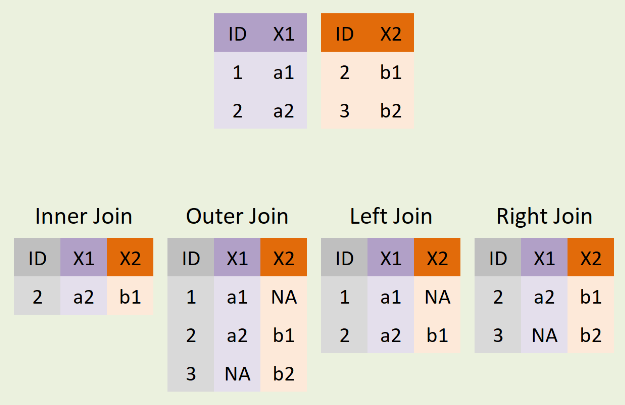

## 정리하기

In [ ]:
# 추가한 변수를 pandas 코드에 바로 활용하기
exam.assign(total = exam['math'] + exam['english'] + exam['science']) \
    .sort_values('total').head()

## 6. 집단별로 요약하기
exam.groupby('nclass').agg(mean_math = ('math', 'mean'))

# 각 집단별로 다시 집단 나누기
mpg.groupby(['manufacturer', 'drv']).agg(mean_cty = ('cty', 'mean'))

## 7. 데이터 합치기
pd.merge(test1, test2, how = 'left', on = 'id')  # 가로로 합치기
pd.concat([group_a, group_b])                    # 세로로 합치기

,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
0,6,70
1,7,83
2,8,65
3,9,95
4,10,80


## 종료